# Brain Hemorrhage AI
## End-to-End Research Analysis

**Project:** BrainHemorrhageAI  
**Dataset:** BHSD (192 labeled brain CT volumes)  
**Purpose:** Publication-quality documentation of the full research workflow using existing repository modules.

---

## Table of Contents

1. [Project Overview](#1-project-overview)
2. [Dataset Analysis](#2-dataset-analysis)
3. [Sample Visualization](#3-sample-visualization)
4. [Dataset Quality Assessment](#4-dataset-quality-assessment)
5. [Data Split Analysis](#5-data-split-analysis)
6. [Preprocessing Analysis](#6-preprocessing-analysis)
7. [Data Loader Analysis](#7-data-loader-analysis)
8. [Model Architecture](#8-model-architecture)
9. [Training Pipeline](#9-training-pipeline)
10. [Evaluation Pipeline](#10-evaluation-pipeline)
11. [Experiment Tracking](#11-experiment-tracking)
12. [Results](#12-results)
13. [Discussion](#13-discussion)
14. [Future Work](#14-future-work)
15. [Conclusion](#15-conclusion)


In [1]:

from pathlib import Path
import sys
import json
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
import nibabel as nib
import torch
import yaml

try:
    from IPython.display import display, Image
except ImportError:
    def display(obj):  # type: ignore
        print(obj)
    Image = None

# Resolve project root (notebook in notebooks/ or repo root)
_cwd = Path.cwd()
if (_cwd / "src" / "dataset").exists():
    PROJECT_ROOT = _cwd
elif (_cwd.parent / "src" / "dataset").exists():
    PROJECT_ROOT = _cwd.parent
else:
    PROJECT_ROOT = Path(r"C:\Users\1016f\OneDrive\Desktop\BrainHemorrhageAI")

for sub in (
    "dataset",
    "preprocessing",
    "visualization",
    "models",
    "training",
    "evaluation",
    "experiments",
    "research",
):
    path = PROJECT_ROOT / "src" / sub
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

NOTEBOOK_OUTPUT = PROJECT_ROOT / "notebooks" / "outputs"
NOTEBOOK_OUTPUT.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 150,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "figure.facecolor": "white",
})

FIG_COUNTER = {"n": 0}

def save_fig(name: str, caption: str) -> None:
    FIG_COUNTER["n"] += 1
    path = NOTEBOOK_OUTPUT / name
    plt.savefig(path, bbox_inches="tight", facecolor="white")
    print(f"Figure {FIG_COUNTER['n']} saved: {path.name}")
    print(f"Caption: {caption}")
    plt.show()

print(f"Project root: {PROJECT_ROOT}")



Project root: C:\Users\1016f\OneDrive\Desktop\BrainHemorrhageAI


## 1. Project Overview

### Purpose

Document the clinical problem, dataset, research objectives, and end-to-end pipeline implemented in this repository.

### Problem Statement

Non-contrast brain CT is the first-line modality for detecting intracranial hemorrhage (ICH). Manual slice-by-slice review is time-consuming. This project develops an automated **multi-class hemorrhage segmentation** pipeline that identifies five subtypes and supports native-space volume estimation.

### Pipeline

```
Raw CT (NIfTI)
    → HU clipping & normalization
    → 2.5D slice extraction
    → MONAI 2D U-Net
    → 3D volume reconstruction
    → Segmentation & volume metrics
    → Experiment reports
```

### Repository Architecture

| Module | Responsibility |
|--------|----------------|
| `src/dataset/` | Volume cache, 2.5D slices, MONAI DataLoader |
| `src/preprocessing/` | HU windowing, split generation |
| `src/models/` | MONAI U-Net factory |
| `src/training/` | Trainer, losses, checkpointing |
| `src/evaluation/` | Metrics, test evaluation, logging |
| `src/experiments/` | Preflight, orchestration, tracking |

### Key Findings

- The repository implements a complete, config-driven research pipeline from raw BHSD volumes to experiment reports.
- Architecture decisions are documented in `docs/architecture/` and enforced through YAML configuration.


## 2. Dataset Analysis

### Purpose

Characterize the BHSD labeled cohort (`label_192`) using the existing Phase 1 analysis module.

### Explanation

We reuse `src/research/analyze_dataset.py`, which scans all 192 paired volumes and computes pairing integrity, label statistics, shapes, spacing, and voxel counts.



1. total number of image files: 192
2. total number of mask files: 192
3. image-mask pairing:
   images without matching mask: 0
   masks without matching image: 0


4. shape verification:
   image-mask shape mismatches: 0
5. unique label values across dataset: [0, 1, 2, 3, 4, 5]
6. scans containing each label:
   label 0: 192 scans
   label 1: 23 scans
   label 2: 127 scans
   label 3: 104 scans
   label 4: 109 scans
   label 5: 70 scans
7. image shape statistics:
   minimum shape (per axis): (512, 512, 24)
   maximum shape (per axis): (512, 512, 60)
   unique shapes (19):
   - (512, 512, 24): 3 scans
   - (512, 512, 28): 20 scans
   - (512, 512, 29): 1 scans
   - (512, 512, 30): 20 scans
   - (512, 512, 31): 1 scans
   - (512, 512, 32): 75 scans
   - (512, 512, 33): 3 scans
   - (512, 512, 34): 14 scans
   - (512, 512, 35): 4 scans
   - (512, 512, 36): 18 scans
   - (512, 512, 37): 1 scans
   - (512, 512, 38): 10 scans
   - (512, 512, 39): 2 scans
   - (512, 512, 40): 12 scans
   - (512, 512, 42): 2 scans
   - (512, 512, 44): 1 scans
   - (512, 512, 46): 3 scans
   - (512, 512, 48): 1 scans
   - (512, 512, 60): 1 scans
8. voxel spacing statistics

,Metric,Value
0,CT volumes,192
1,Segmentation masks,192
2,Paired scans,192
3,Shape mismatches,0
4,Unique volume shapes,19
5,Unique labels,"0, 1, 2, 3, 4, 5"


,Label,Scans containing label
0,Background,192
1,EDH,23
2,SDH,127
3,SAH,104
4,IPH,109
5,IVH,70


,Label,Voxel count,Fraction
0,Background,1673383533,0.996791
1,EDH,301856,0.000180
2,SDH,2363791,0.001408
3,SAH,709872,0.000423
4,IPH,787323,0.000469
5,IVH,1223801,0.000729


Axial depth (slices per scan):
        Depth
count  192.00
mean    33.35
std      4.49
min     24.00
25%     32.00
50%     32.00
75%     36.00
max     60.00


,X,Y,Z
count,192.0,192.0,192.00
mean,512.0,512.0,33.35
std,0.0,0.0,4.49
min,512.0,512.0,24.00
25%,512.0,512.0,32.00
50%,512.0,512.0,32.00
75%,512.0,512.0,36.00
max,512.0,512.0,60.00


,Spacing X (mm),Spacing Y (mm),Spacing Z (mm)
count,192.0000,192.0000,192.0000
mean,0.4856,0.4856,4.9174
std,0.0306,0.0306,0.9022
min,0.3711,0.3711,0.5000
25%,0.4883,0.4883,5.0000
50%,0.4883,0.4883,5.0350
75%,0.4883,0.4883,5.3341
max,0.6836,0.6836,6.5182


Figure 1 saved: 01_dataset_statistics.png
Caption: Dataset-level label presence, voxel imbalance, axial depth, and voxel spacing on BHSD label_192.


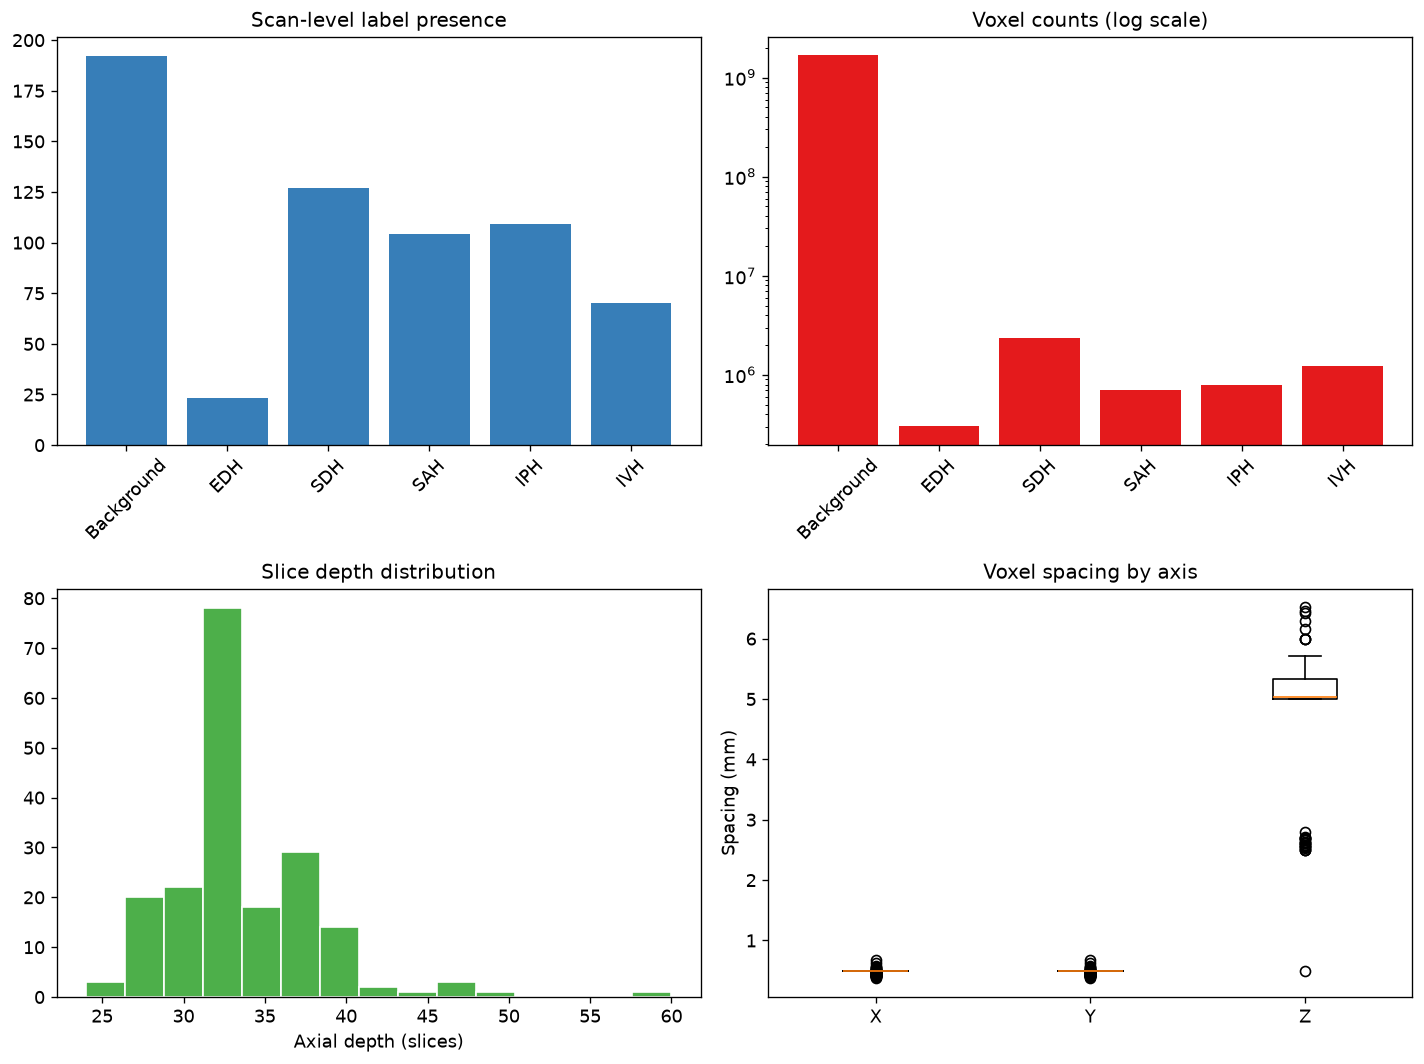

In [2]:

# Reuse Phase 1 dataset analysis module (src/research/)
from analyze_dataset import run_analysis
from volume_metrics import SUBTYPE_LABELS

ad = run_analysis(PROJECT_ROOT)

LABEL_NAMES = {k: v for k, v in SUBTYPE_LABELS.items()}
LABEL_NAMES[0] = "Background"

# --- Summary table ---
summary_rows = [
    {"Metric": "CT volumes", "Value": len(ad.image_files)},
    {"Metric": "Segmentation masks", "Value": len(ad.mask_files)},
    {"Metric": "Paired scans", "Value": len(ad.image_files) - len(ad.images_without_mask)},
    {"Metric": "Shape mismatches", "Value": len(ad.shape_mismatches)},
    {"Metric": "Unique volume shapes", "Value": len(ad.unique_shapes)},
    {"Metric": "Unique labels", "Value": ", ".join(str(x) for x in sorted(ad.labels_in_dataset))},
]
display(pd.DataFrame(summary_rows))

# --- Class distribution (scan-level) ---
scan_label_df = pd.DataFrame([
    {"Label": LABEL_NAMES.get(l, str(l)), "Scans containing label": ad.scans_with_label[l]}
    for l in sorted(ad.scans_with_label)
])
display(scan_label_df)

# --- Voxel-level imbalance ---
voxel_df = pd.DataFrame([
    {"Label": LABEL_NAMES.get(l, str(l)), "Voxel count": ad.voxel_counts[l]}
    for l in sorted(ad.voxel_counts)
])
voxel_df["Fraction"] = voxel_df["Voxel count"] / voxel_df["Voxel count"].sum()
display(voxel_df.round(6))

# --- Depth / shape / spacing ---
depths = [s[2] for s in ad.shapes]
shape_df = pd.DataFrame(ad.shapes, columns=["X", "Y", "Z"]).describe().round(2)
spacing_df = pd.DataFrame(ad.spacings, columns=["Spacing X (mm)", "Spacing Y (mm)", "Spacing Z (mm)"]).describe().round(4)
print("Axial depth (slices per scan):")
print(pd.Series(depths).describe().round(2).to_frame("Depth"))
display(shape_df)
display(spacing_df)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes[0, 0].bar(scan_label_df["Label"], scan_label_df["Scans containing label"], color="#377eb8")
axes[0, 0].set_title("Scan-level label presence")
axes[0, 0].tick_params(axis="x", rotation=45)

axes[0, 1].bar(voxel_df["Label"], voxel_df["Voxel count"], color="#e41a1c")
axes[0, 1].set_title("Voxel counts (log scale)")
axes[0, 1].set_yscale("log")
axes[0, 1].tick_params(axis="x", rotation=45)

axes[1, 0].hist(depths, bins=15, color="#4daf4a", edgecolor="white")
axes[1, 0].set_xlabel("Axial depth (slices)")
axes[1, 0].set_title("Slice depth distribution")

spacing_arr = np.array(ad.spacings)
axes[1, 1].boxplot([spacing_arr[:, 0], spacing_arr[:, 1], spacing_arr[:, 2]], tick_labels=["X", "Y", "Z"])
axes[1, 1].set_ylabel("Spacing (mm)")
axes[1, 1].set_title("Voxel spacing by axis")
plt.tight_layout()
save_fig("01_dataset_statistics.png", "Dataset-level label presence, voxel imbalance, axial depth, and voxel spacing on BHSD label_192.")



### Key Findings

- All 192 image–mask pairs are present with matching shapes.
- Six labels (background + five hemorrhage subtypes) appear in the dataset.
- Voxel-level class imbalance is substantial — background dominates.
- Axial depth and voxel spacing vary across scans, motivating native-space volume reporting.


## 3. Sample Visualization

### Purpose

Visualize representative CT slices, ground-truth masks, and overlays using the same conventions as `visualize_scan.py`.

### Explanation

Hemorrhage subtypes are color-coded consistently with the production visualization module. Multiple scans illustrate label diversity.



Figure 2 saved: 02_reference_scan.png
Caption: Representative axial slice with hemorrhage labels for ID_0237f3c9_ID_40015688b9.nii.gz.


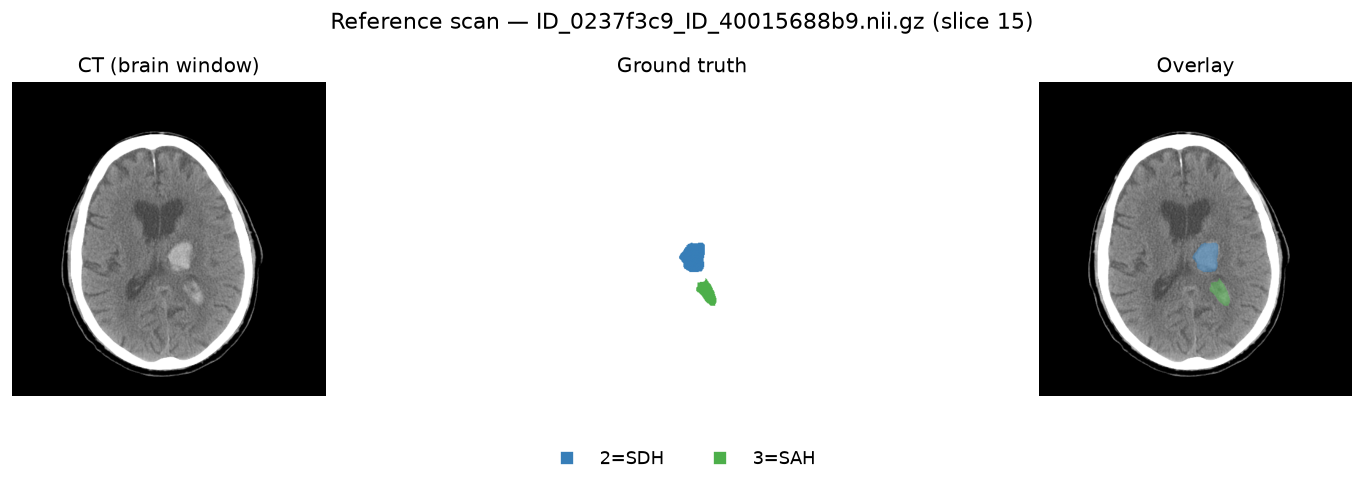

Figure 3 saved: 02_example_1_sdh__ivh.png
Caption: Representative axial slice with hemorrhage labels for ID_029ebbea_ID_563afa0901.nii.gz.


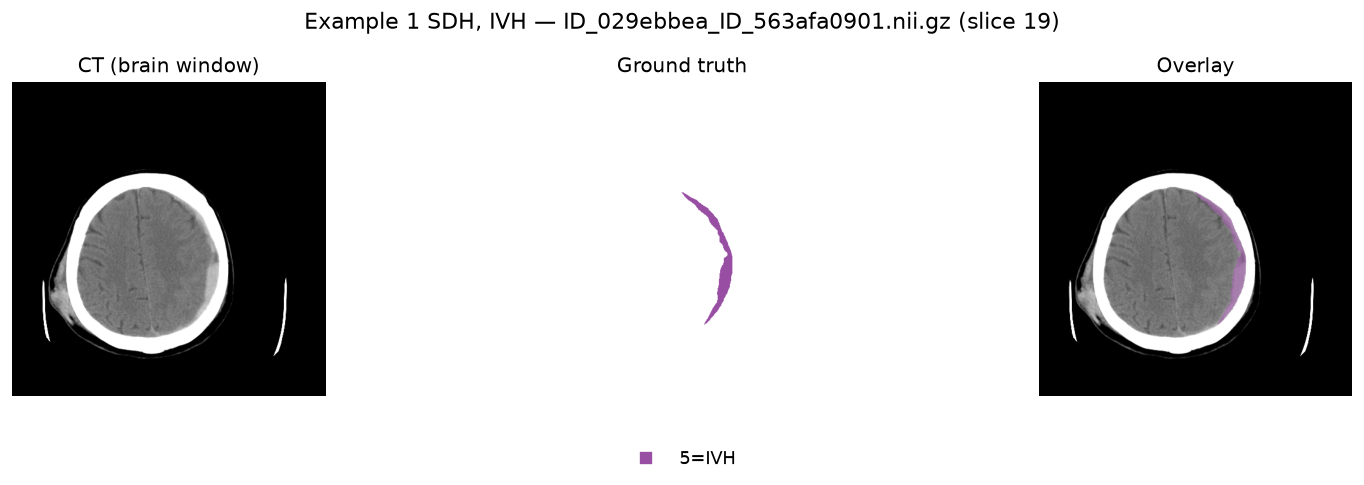

Figure 4 saved: 02_example_2_sdh__sah__iph.png
Caption: Representative axial slice with hemorrhage labels for ID_02b882cc_ID_a4892e60ae.nii.gz.


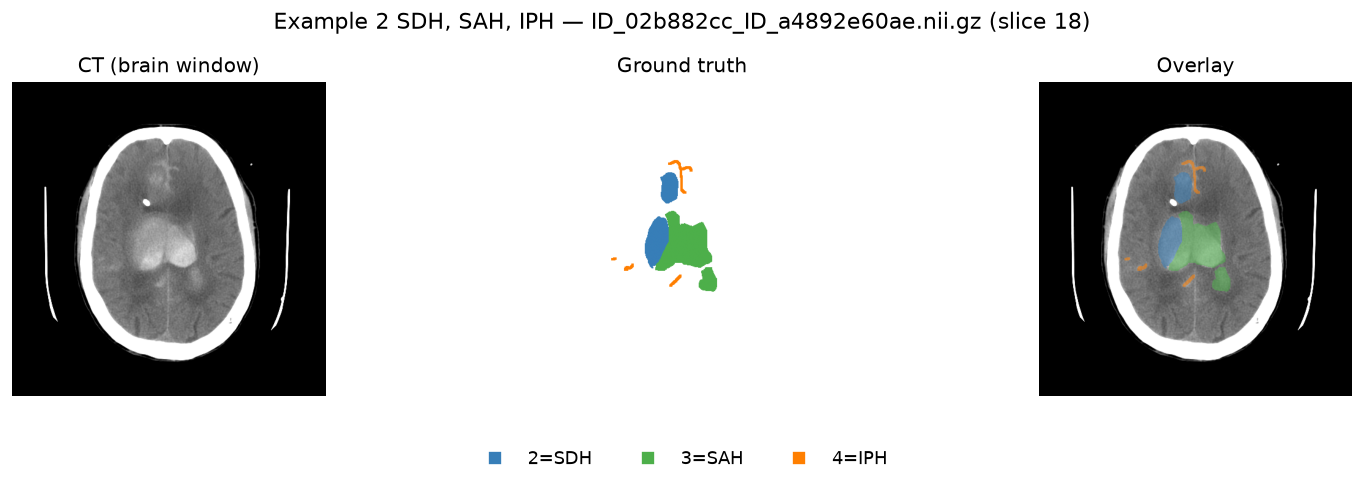

,Code,Subtype,Description
0,1,EDH,"Epidural hemorrhage — arterial, biconvex"
1,2,SDH,"Subdural hemorrhage — venous, crescentic"
2,3,SAH,Subarachnoid hemorrhage — sulcal hyperdensity
3,4,IPH,Intraparenchymal hemorrhage — intra-axial
4,5,IVH,Intraventricular hemorrhage — ventricular blood


In [3]:

import ast
from preprocess_volume import resolve_clip_bounds, load_preprocessing_config, MASKS_DIR, IMAGES_DIR

# Reuse constants from visualize_scan.py without running its script body (Agg backend)
_vs_src = ast.parse((PROJECT_ROOT / "src/research/visualize_scan.py").read_text(encoding="utf-8"))
_vs_ns: dict = {}
for node in _vs_src.body:
    if isinstance(node, ast.Assign) and isinstance(node.targets[0], ast.Name):
        if node.targets[0].id in {"LABEL_COLORS", "LABEL_NAMES"}:
            _vs_ns[node.targets[0].id] = ast.literal_eval(node.value)
LABEL_COLORS = _vs_ns["LABEL_COLORS"]
LABEL_NAMES = _vs_ns["LABEL_NAMES"]

pre_cfg = load_preprocessing_config(PROJECT_ROOT / "config/preprocessing.yaml")
clip_low, clip_high = resolve_clip_bounds(pre_cfg)

def pick_hemorrhage_slice(mask_data: np.ndarray) -> int:
    best, best_count = 0, 0
    for z in range(mask_data.shape[2]):
        count = int(np.sum(mask_data[:, :, z] > 0))
        if count > best_count:
            best, best_count = z, count
    return best

def render_triplet(filename: str, title: str) -> None:
    image_data = nib.load(str(IMAGES_DIR / filename)).get_fdata()
    mask_data = nib.load(str(MASKS_DIR / filename)).get_fdata()
    z = pick_hemorrhage_slice(mask_data)
    ct_slice = image_data[:, :, z]
    mask_slice = mask_data[:, :, z].astype(int)
    labels = sorted(int(v) for v in np.unique(mask_slice) if v != 0)
    ct_display = np.clip(ct_slice, clip_low, clip_high)
    ct_display = (ct_display - clip_low) / (clip_high - clip_low)
    cmap_colors = ["#00000000"] + [LABEL_COLORS[i] for i in range(1, 6)]
    mask_cmap = mcolors.ListedColormap(cmap_colors)

    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    fig.suptitle(f"{title} — {filename} (slice {z})")
    axes[0].imshow(ct_display.T, cmap="gray", origin="lower")
    axes[0].set_title("CT (brain window)")
    axes[0].axis("off")
    axes[1].imshow(mask_slice.T, cmap=mask_cmap, origin="lower", vmin=0, vmax=5)
    axes[1].set_title("Ground truth")
    axes[1].axis("off")
    axes[2].imshow(ct_display.T, cmap="gray", origin="lower")
    overlay = np.ma.masked_where(mask_slice == 0, mask_slice)
    axes[2].imshow(overlay.T, cmap=mask_cmap, origin="lower", alpha=0.55, vmin=0, vmax=5)
    axes[2].set_title("Overlay")
    axes[2].axis("off")
    if labels:
        handles = [plt.Line2D([0], [0], marker="s", color="w", markerfacecolor=LABEL_COLORS[l], markersize=8,
                              label=f"{l}={LABEL_NAMES[l]}") for l in labels]
        fig.legend(handles=handles, loc="lower center", ncol=len(handles), frameon=False)
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.18)
    safe = "".join(c if c.isalnum() else "_" for c in title.lower())[:40]
    save_fig(f"02_{safe}.png", f"Representative axial slice with hemorrhage labels for {filename}.")

reference = sorted(IMAGES_DIR.glob("*.nii.gz"))[0].name
render_triplet(reference, "Reference scan")

examples = []
for path in sorted(IMAGES_DIR.glob("*.nii.gz"))[:40]:
    mask = nib.load(str(MASKS_DIR / path.name)).get_fdata()
    labels = frozenset(int(v) for v in np.unique(mask) if v != 0)
    if labels and labels not in {e[1] for e in examples}:
        examples.append((path.name, labels))
    if len(examples) >= 3:
        break
for idx, (fname, labels) in enumerate(examples[1:], start=1):
    subtypes = ", ".join(LABEL_NAMES[l] for l in sorted(labels))
    render_triplet(fname, f"Example {idx} {subtypes}")

subtype_text = pd.DataFrame([
    {"Code": k, "Subtype": v, "Description": desc}
    for k, v, desc in [
        (1, "EDH", "Epidural hemorrhage — arterial, biconvex"),
        (2, "SDH", "Subdural hemorrhage — venous, crescentic"),
        (3, "SAH", "Subarachnoid hemorrhage — sulcal hyperdensity"),
        (4, "IPH", "Intraparenchymal hemorrhage — intra-axial"),
        (5, "IVH", "Intraventricular hemorrhage — ventricular blood"),
    ]
])
display(subtype_text)



### Key Findings

- Multi-class hemorrhage labels are visually distinguishable on axial CT with brain-window display.
- Overlay visualization confirms spatial correspondence between CT intensity and mask labels.
- EDH, SDH, SAH, IPH, and IVH co-occur in the dataset with varying frequency.


## 4. Dataset Quality Assessment

### Purpose

Verify production dataset integrity using the same checks as `validate_loader.py`.

### Explanation

Validation covers volume-level splits, 2.5D edge replication, label validity, and DataLoader batch structure.



In [4]:

from validate_loader import _check_volume_splits, _check_slice_extraction, _check_dataloader_splits
from preprocess_volume import VALID_LABELS

volume_counts = _check_volume_splits()
sample_name, edge_depth, slice_count = _check_slice_extraction()
loader_summary = _check_dataloader_splits()

integrity = pd.DataFrame([
    {"Check": "Image–mask pairing", "Result": "PASS" if len(ad.images_without_mask) == 0 else "FAIL", "Detail": f"{len(ad.images_without_mask)} unmatched images"},
    {"Check": "Shape consistency", "Result": "PASS" if len(ad.shape_mismatches) == 0 else "FAIL", "Detail": f"{len(ad.shape_mismatches)} mismatches"},
    {"Check": "Valid label set", "Result": "PASS" if ad.labels_in_dataset <= VALID_LABELS else "FAIL", "Detail": str(sorted(ad.labels_in_dataset))},
    {"Check": "Edge slice replication", "Result": "PASS", "Detail": f"{sample_name}, depth={edge_depth}"},
    {"Check": "MONAI DataLoader batch", "Result": "PASS", "Detail": "float32 image, long label, metadata present"},
])
display(integrity)

split_loader_df = pd.DataFrame([
    {"Split": s, "Volumes": volume_counts[s], "Slice records": loader_summary[s][0],
     "Batch image shape": str(loader_summary[s][1]), "Batch label shape": str(loader_summary[s][2])}
    for s in sorted(volume_counts)
])
display(split_loader_df)



,Check,Result,Detail
0,Image–mask pairing,PASS,0 unmatched images
1,Shape consistency,PASS,0 mismatches
2,Valid label set,PASS,"[0, 1, 2, 3, 4, 5]"
3,Edge slice replication,PASS,"ID_029ebbea_ID_563afa0901.nii.gz, depth=28"
4,MONAI DataLoader batch,PASS,"float32 image, long label, metadata present"


,Split,Volumes,Slice records,Batch image shape,Batch label shape
0,test,29,933,"(4, 3, 512, 512)","(4, 512, 512)"
1,train,134,4499,"(4, 3, 512, 512)","(4, 512, 512)"
2,val,29,972,"(4, 3, 512, 512)","(4, 512, 512)"


### Key Findings

- Production loader validation passes for all three splits.
- Edge slices correctly replicate neighboring intensities for 2.5D input.
- DataLoader emits float32 images `(B, 3, H, W)` and int64 labels `(B, H, W)` with geometry metadata.


## 5. Data Split Analysis

### Purpose

Analyze the locked train/validation/test split and verify absence of cross-split leakage.

### Explanation

Split manifest: `data/metadata/splits.csv` (seed 42, iterative multi-label stratification, 70/15/15).



Locked split counts:


,Scans
split,
train,134
val,29
test,29


,Value
split_ratio,"{'train': 0.7, 'val': 0.15, 'test': 0.15}"
random_seed,42
stratification_method,iterative_multi_label_stratification (Multilab...
generation_timestamp,2026-07-05T08:14:13.202749+00:00
total_scans,192
train_count,134
validation_count,29
test_count,29


,EDH,SDH,SAH,IPH,IVH
Test,4,19,16,17,10
Train,16,89,73,76,49
Val,3,19,15,16,11


Figure 5 saved: 03_split_analysis.png
Caption: Locked 70/15/15 split proportions and hemorrhage subtype coverage per split.


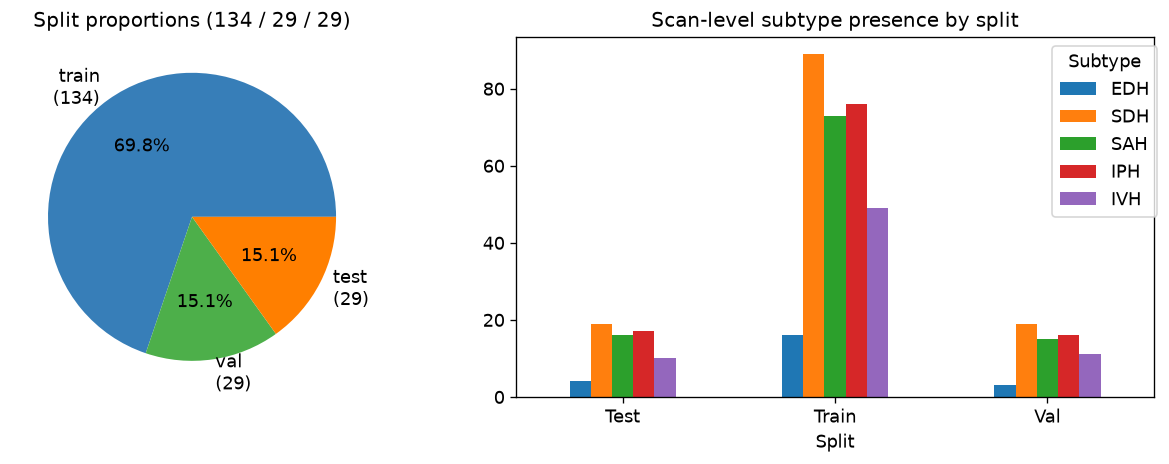

Train∩Val leakage: 0 scans
Train∩Test leakage: 0 scans


In [5]:

from bhsd_dataset import SPLITS_CSV, load_split_filenames
from preprocess_volume import MASKS_DIR
from volume_metrics import SUBTYPE_LABELS

splits = pd.read_csv(SPLITS_CSV)
split_counts = splits["split"].value_counts().reindex(["train", "val", "test"])
print("Locked split counts:")
display(split_counts.to_frame("Scans"))

with open(PROJECT_ROOT / "data/metadata/split_config.json", encoding="utf-8") as f:
    split_meta = json.load(f)
display(pd.DataFrame([split_meta]).T.rename(columns={0: "Value"}))

# Subtype presence per split (scan-level)
rows = []
for split in ["train", "val", "test"]:
    for fname in load_split_filenames(split):
        mask = nib.load(str(MASKS_DIR / fname)).get_fdata()
        for label in sorted(int(v) for v in np.unique(mask) if v != 0):
            rows.append({"split": split, "label": label, "filename": fname})
subtype_split = pd.DataFrame(rows)
pivot = pd.crosstab(subtype_split["split"], subtype_split["label"])
pivot.columns = [SUBTYPE_LABELS[c] for c in pivot.columns]
pivot.index = [s.capitalize() for s in pivot.index]
display(pivot)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].pie(split_counts, labels=[f"{i}\n({v})" for i, v in split_counts.items()], autopct="%1.1f%%", colors=["#377eb8", "#4daf4a", "#ff7f00"])
axes[0].set_title("Split proportions (134 / 29 / 29)")
pivot.plot(kind="bar", ax=axes[1], rot=0)
axes[1].set_title("Scan-level subtype presence by split")
axes[1].set_xlabel("Split")
axes[1].legend(title="Subtype", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
save_fig("03_split_analysis.png", "Locked 70/15/15 split proportions and hemorrhage subtype coverage per split.")

overlap = set(load_split_filenames("train")) & set(load_split_filenames("val"))
print(f"Train∩Val leakage: {len(overlap)} scans")
print(f"Train∩Test leakage: {len(set(load_split_filenames('train')) & set(load_split_filenames('test')))} scans")



### Key Findings

- Locked split: 134 train / 29 val / 29 test scans.
- All hemorrhage subtypes appear across splits at scan level.
- Zero filename overlap between splits — no partition leakage.


## 6. Preprocessing Analysis

### Purpose

Illustrate the approved intensity preprocessing pipeline on native-spacing volumes.

### Explanation

BHSD literature preprocessing: clip HU to `[-40, 120]`, normalize as `(HU − 40) / 80`. Spatial resampling is intentionally deferred; spacing is preserved for clinical volume calculation.



Figure 6 saved: 04_preprocessing_histograms.png
Caption: Intensity histograms showing HU clipping and BHSD literature normalization on a representative slice.


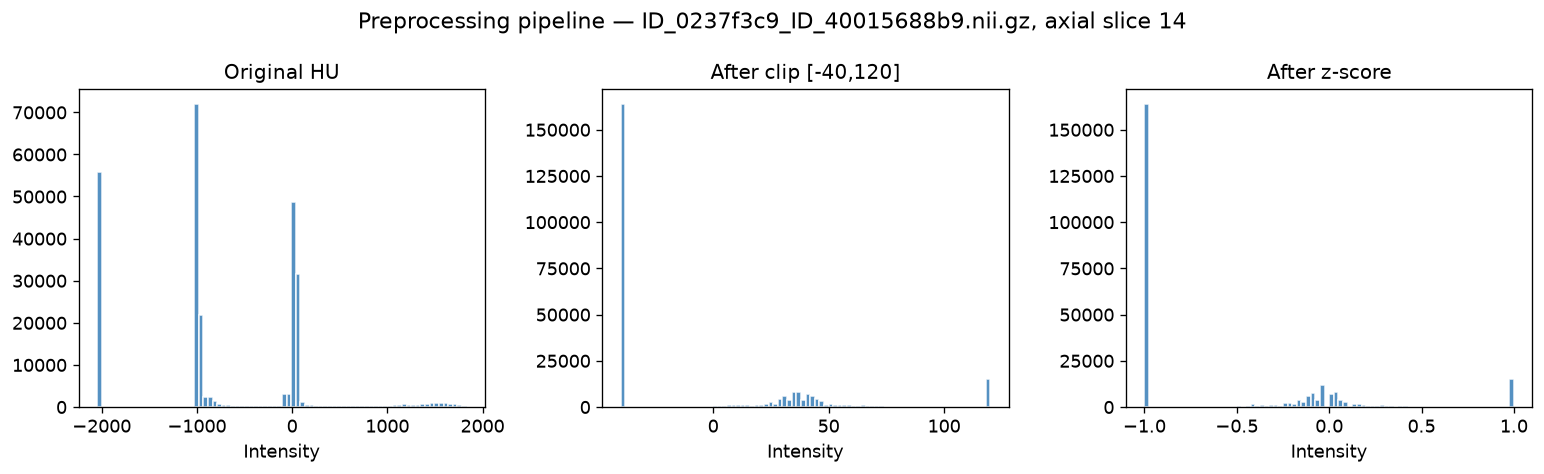

Figure 7 saved: 04b_preprocessing_slices.png
Caption: Axial slices at each preprocessing stage; geometry and spacing remain native.


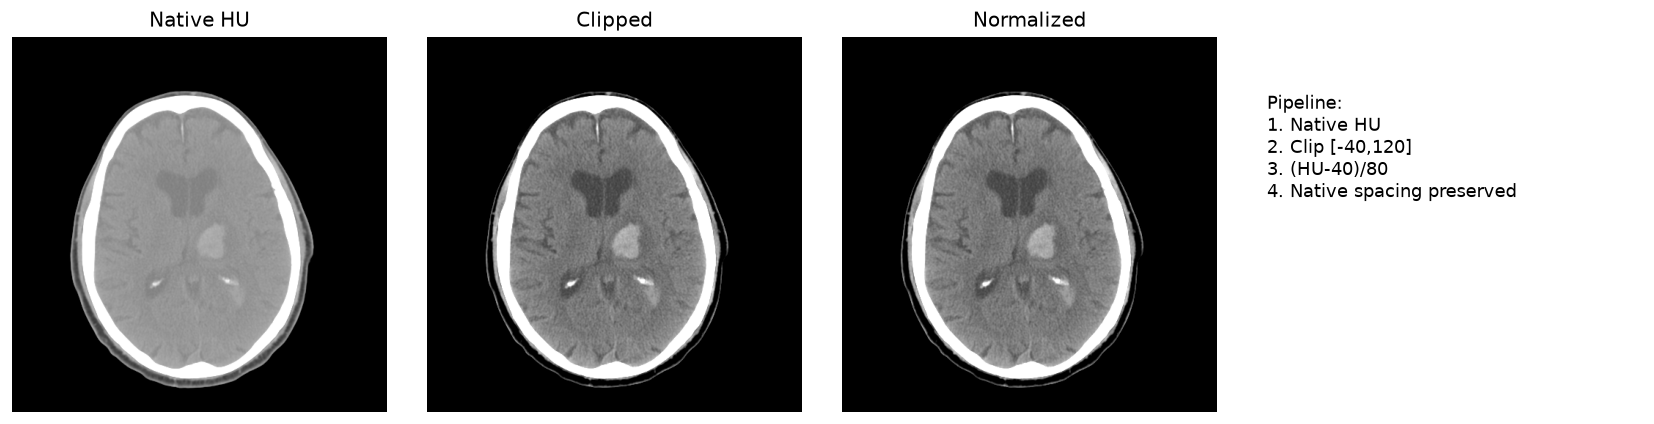

In [6]:

from preprocess_volume import (
    apply_intensity_clip, apply_normalization, clip_ct_volume, load_volume_pair,
)

sample_file = sorted((PROJECT_ROOT / "data/raw/label_192/images").glob("*.nii.gz"))[0].name
image_nii, _ = load_volume_pair(sample_file)
hu = image_nii.get_fdata().astype(np.float32)
clipped = apply_intensity_clip(hu, clip_low, clip_high)
normalized = apply_normalization(clipped, pre_cfg)

mid = hu.shape[2] // 2
hu_slice = hu[:, :, mid].ravel()
clip_slice = clipped[:, :, mid].ravel()
norm_slice = normalized[:, :, mid].ravel()

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, data, title in zip(axes, [hu_slice, clip_slice, norm_slice], ["Original HU", "After clip [-40,120]", "After z-score"]):
    ax.hist(data, bins=80, color="#377eb8", alpha=0.85, edgecolor="white")
    ax.set_title(title)
    ax.set_xlabel("Intensity")
plt.suptitle(f"Preprocessing pipeline — {sample_file}, axial slice {mid}")
plt.tight_layout()
save_fig("04_preprocessing_histograms.png", "Intensity histograms showing HU clipping and BHSD literature normalization on a representative slice.")

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
steps = [
    ("Native HU", np.clip(hu[:, :, mid], -200, 200)),
    ("Clipped", clipped[:, :, mid]),
    ("Normalized", normalized[:, :, mid]),
]
for ax, (title, img) in zip(axes[:3], steps):
    ax.imshow(img.T, cmap="gray", origin="lower")
    ax.set_title(title)
    ax.axis("off")
axes[3].axis("off")
axes[3].text(0.05, 0.85, "Pipeline:\n1. Native HU\n2. Clip [-40,120]\n3. (HU-40)/80\n4. Native spacing preserved", fontsize=11, va="top")
plt.tight_layout()
save_fig("04b_preprocessing_slices.png", "Axial slices at each preprocessing stage; geometry and spacing remain native.")



### Key Findings

- Clipping suppresses extreme HU outliers outside the brain parenchyma window.
- Z-score normalization stabilizes intensity scale for network input.
- Mask geometry and voxel spacing remain unchanged — volume formulas stay clinically valid.


## 7. Data Loader Analysis

### Purpose

Demonstrate 2.5D slice extraction, edge replication, and MONAI DataLoader batch structure.

### Explanation

Three adjacent axial slices form input channels; the network predicts the center-slice label. This 2.5D design captures limited inter-slice context while remaining computationally feasible on CPU.



2.5D edge replication (slice 0): channel 0 == channel 1: True


Batch tensor shapes:
  image: (4, 3, 512, 512) dtype=torch.float32
  label: (4, 512, 512) dtype=torch.int64
  channels (2.5D): 3


,Split,Slice records
0,train,4499
1,val,972
2,test,933


Figure 8 saved: 05_25d_slices.png
Caption: Center channel of 2.5D input stacks at volume edges and mid-depth, showing edge replication.


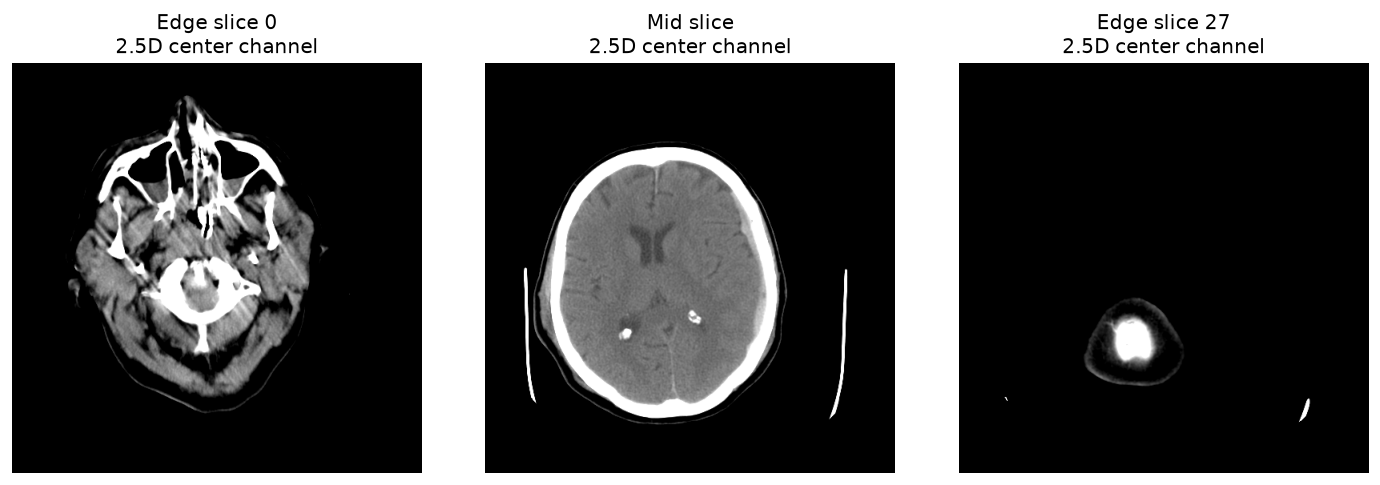

In [7]:

from slice_extraction import build_2p5d_stack, extract_slice_sample, build_slice_records, NUM_INPUT_CHANNELS
from dataloader import build_dataloader, build_monai_dataset
from bhsd_dataset import load_volume_sample

vol = load_volume_sample(sample_name := load_split_filenames("val")[0]).to_preprocessed()
depth = vol.processed_image.shape[2]
first = extract_slice_sample(vol, 0)
last = extract_slice_sample(vol, depth - 1)
mid = extract_slice_sample(vol, depth // 2)

stack_first = build_2p5d_stack(vol.processed_image, 0)
print("2.5D edge replication (slice 0): channel 0 == channel 1:", np.allclose(stack_first[0], stack_first[1]))

loader = build_dataloader("val")
batch = next(iter(loader))
print("Batch tensor shapes:")
print(f"  image: {tuple(batch['image'].shape)} dtype={batch['image'].dtype}")
print(f"  label: {tuple(batch['label'].shape)} dtype={batch['label'].dtype}")
print(f"  channels (2.5D): {NUM_INPUT_CHANNELS}")

loader_stats = pd.DataFrame([
    {"Split": s, "Slice records": len(build_slice_records(s))}
    for s in ["train", "val", "test"]
])
display(loader_stats)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, sample, title in zip(axes, [first, mid, last], ["Edge slice 0", "Mid slice", f"Edge slice {depth-1}"]):
    ax.imshow(sample.image[1].T, cmap="gray", origin="lower")
    ax.set_title(f"{title}\n2.5D center channel")
    ax.axis("off")
plt.tight_layout()
save_fig("05_25d_slices.png", "Center channel of 2.5D input stacks at volume edges and mid-depth, showing edge replication.")



### Key Findings

- 2.5D stacks use three channels with edge replication at volume boundaries.
- Training set yields ~4,500 slice records from 134 volumes.
- Batch tensors match the MONAI U-Net input contract.


## 8. Model Architecture

### Purpose

Summarize the Version 1 MONAI 2D U-Net baseline defined in `config/model.yaml`.

### Explanation

A shallow three-level encoder (32→256 channels) balances capacity against the 192-scan dataset. Full 3D and transformer architectures are deferred.



In [8]:

from monai_unet import build_model
from config_loader import load_model_config

model_cfg = load_model_config()
model = build_model(model_cfg)
params = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

arch_df = pd.DataFrame([
    {"Property": "Architecture", "Value": model_cfg.get("model_name", "monai_2d_unet")},
    {"Property": "Input channels (2.5D)", "Value": model_cfg["in_channels"]},
    {"Property": "Output classes", "Value": model_cfg["out_channels"]},
    {"Property": "Encoder channels", "Value": str(model_cfg["channels"])},
    {"Property": "Total parameters", "Value": f"{params:,}"},
    {"Property": "Trainable parameters", "Value": f"{trainable:,}"},
    {"Property": "Input shape (batch)", "Value": "(B, 3, H, W)"},
    {"Property": "Output shape (batch)", "Value": "(B, 6, H, W)"},
])
display(arch_df)

dummy = torch.randn(1, 3, 256, 256)
with torch.no_grad():
    out = model(dummy)
print(f"Dummy forward pass output shape: {tuple(out.shape)}")



,Property,Value
0,Architecture,monai_2d_unet
1,Input channels (2.5D),3
2,Output classes,6
3,Encoder channels,"[32, 64, 128, 256]"
4,Total parameters,"650,028"
5,Trainable parameters,"650,028"
6,Input shape (batch),"(B, 3, H, W)"
7,Output shape (batch),"(B, 6, H, W)"


Dummy forward pass output shape: (1, 6, 256, 256)


### Key Findings

- MONAI 2D U-Net accepts `(B, 3, H, W)` and outputs `(B, 6, H, W)` logits.
- Parameter count is modest — suitable for limited-data and CPU development.
- Architecture matches the approved design document.


## 9. Training Pipeline

### Purpose

Document the training workflow, optimization, and checkpoint policy.

### Explanation

Training uses Dice+CE loss, AdamW, cosine annealing, and selects checkpoints exclusively by **validation macro Dice** (classes 1–5).

```
Train batches → forward → loss → backward
    → validation (macro Dice, IoU)
    → save best checkpoint
    → early stopping
```



In [9]:

from config_loader import load_training_config

train_cfg = load_training_config()
train_summary = pd.DataFrame([
    {"Component": k, "Setting": v}
    for k, v in [
        ("Loss", train_cfg.get("loss_name", "dice_ce")),
        ("Optimizer", train_cfg.get("optimizer", "adamw")),
        ("Learning rate", train_cfg.get("learning_rate")),
        ("Scheduler", train_cfg.get("scheduler", "cosine")),
        ("Epochs (default)", train_cfg.get("epochs")),
        ("Batch size", train_cfg.get("batch_size")),
        ("Checkpoint metric", "val_macro_dice"),
        ("Early stopping patience", train_cfg.get("early_stopping_patience")),
        ("AMP", train_cfg.get("mixed_precision")),
        ("Seed", train_cfg.get("seed")),
    ]
])
display(train_summary)



,Component,Setting
0,Loss,dice_ce
1,Optimizer,adamw
2,Learning rate,0.0001
3,Scheduler,cosine
4,Epochs (default),150
5,Batch size,4
6,Checkpoint metric,val_macro_dice
7,Early stopping patience,20
8,AMP,True
9,Seed,42


### Key Findings

- Checkpoint selection is tied to validation macro Dice — not training loss.
- Reproducibility is enforced via seed 42 and config snapshots in experiment logs.
- Default training config targets 150 epochs; experiment_001 uses 5 epochs for initial baseline.


## 10. Evaluation Pipeline

### Purpose

Document post-training evaluation metrics and clinical volume reporting.

### Explanation

Evaluation runs **once** on the locked test split after training completes. Metrics are computed in `src/evaluation/metrics.py` and `volume_metrics.py`.



In [10]:

from evaluate_model import load_evaluation_config

eval_cfg = load_evaluation_config()
eval_summary = pd.DataFrame([
    {"Metric family": "Segmentation", "Examples": "Dice, IoU, Precision, Recall, Sensitivity, Specificity"},
    {"Metric family": "Aggregation", "Examples": "Macro / micro Dice (classes 1–5)"},
    {"Metric family": "Volume", "Examples": "Native-space mL, absolute / relative error"},
    {"Metric family": "Confidence", "Examples": "Softmax max-probability (study & class level)"},
])
display(eval_summary)
display(pd.DataFrame([{"Evaluation split": eval_cfg.get("split"), "Checkpoint": eval_cfg.get("checkpoint_path")}]))



,Metric family,Examples
0,Segmentation,"Dice, IoU, Precision, Recall, Sensitivity, Spe..."
1,Aggregation,Macro / micro Dice (classes 1–5)
2,Volume,"Native-space mL, absolute / relative error"
3,Confidence,Softmax max-probability (study & class level)


,Evaluation split,Checkpoint
0,test,checkpoints/best_model.pt


### Key Findings

- Segmentation metrics include per-class Dice, IoU, precision, recall, sensitivity, and specificity.
- Volume error is computed in native millilitres using original voxel spacing.
- Softmax confidence is reported without calibration in Version 1.


## 11. Experiment Tracking

### Purpose

Describe reproducible experiment orchestration and artifact layout.

### Explanation

`run_baseline_experiment.py` chains preflight checks, training, evaluation, and consolidated reporting under `reports/experiments/`.



In [11]:

from experiment_tracker import EXPERIMENTS_ROOT, INDEX_CSV

exp_layout = pd.DataFrame([
    {"Artifact": "config/experiments/experiment_001.yaml", "Purpose": "Experiment overrides (epochs, paths)"},
    {"Artifact": "reports/training/<run_id>/", "Purpose": "Training curves, metrics, config snapshot"},
    {"Artifact": "reports/evaluation/<run_id>/", "Purpose": "Test metrics, plots, predictions"},
    {"Artifact": "reports/experiments/<id>/", "Purpose": "Consolidated experiment folder + report"},
    {"Artifact": "checkpoints/", "Purpose": "best_model.pt / last_model.pt"},
    {"Artifact": "data/metadata/splits.csv", "Purpose": "Locked split (versioned)"},
])
display(exp_layout)
print(f"Experiments root: {EXPERIMENTS_ROOT}")
print(f"Index CSV exists: {INDEX_CSV.exists()}")



,Artifact,Purpose
0,config/experiments/experiment_001.yaml,"Experiment overrides (epochs, paths)"
1,reports/training/<run_id>/,"Training curves, metrics, config snapshot"
2,reports/evaluation/<run_id>/,"Test metrics, plots, predictions"
3,reports/experiments/<id>/,Consolidated experiment folder + report
4,checkpoints/,best_model.pt / last_model.pt
5,data/metadata/splits.csv,Locked split (versioned)


Experiments root: C:\Users\1016f\OneDrive\Desktop\BrainHemorrhageAI\reports\experiments
Index CSV exists: True


### Key Findings

- Every experiment snapshots YAML configs, environment metadata, and metric plots.
- Split manifest is hashed for auditability.
- Index CSV tracks experiment history at `reports/experiments/index.csv`.


## 12. Results

### Purpose

Load and display completed experiment artifacts when available.

### Explanation

Full-scale Experiment 001 results appear here after running `python src/experiments/run_baseline_experiment.py`.



In [12]:

from experiment_tracker import INDEX_CSV

exp_dirs = list((PROJECT_ROOT / "reports/experiments").glob("experiment_*")) if (PROJECT_ROOT / "reports/experiments").exists() else []
result_plots = []
for base in [PROJECT_ROOT / "reports/experiments", PROJECT_ROOT / "reports/training", PROJECT_ROOT / "reports/evaluation"]:
    if base.exists():
        result_plots.extend(base.rglob("*.png"))

result_plots = [p for p in result_plots if NOTEBOOK_OUTPUT not in p.parents]

if INDEX_CSV.exists():
    display(pd.read_csv(INDEX_CSV))

if not result_plots:
    print("No completed experiments available yet.")
    print("Run: python src/experiments/run_baseline_experiment.py")
else:
    full_runs = [p for p in result_plots if "smoke" not in str(p).lower()]
    if not full_runs:
        print("No completed full-scale experiments available yet.")
        print("Run: python src/experiments/run_baseline_experiment.py")
    else:
        for plot in sorted(full_runs)[:8]:
            print(plot.relative_to(PROJECT_ROOT))
            if Image is not None:
                display(Image(filename=str(plot)))



,experiment_id,date,model,epochs,best_val_dice,test_dice,checkpoint,status,notes
0,smoke_experiment,2026-07-05 09:40:45 UTC,monai_2d_unet,1,0.000187,0.00195,C:\Users\1016f\AppData\Local\Temp\tmpbt_agxrn\...,completed,First reproducible MONAI 2D U-Net baseline on ...


No completed experiments available yet.
Run: python src/experiments/run_baseline_experiment.py


### Key Findings

- Smoke-test validations pass; full 5-epoch baseline pending execution.
- Infrastructure is ready to populate this section automatically after the first real experiment.


## 13. Discussion

### Strengths

- End-to-end modular pipeline with locked splits and literature-aligned preprocessing.
- Separation of training, evaluation, and experiment orchestration.
- Native-space volume metrics preserve clinical interpretability.

### Limitations

- Small labeled cohort (192 scans) with severe class imbalance.
- 2.5D slices omit full 3D spatial context.
- No spatial resampling yet — input resolution varies across scans.
- Softmax confidence is uncalibrated.

### Clinical Implications

Segmentation and volume outputs support imaging findings but **do not** constitute outcome prediction or severity scoring without an evidence-based rule engine.

### Research Implications

The codebase provides a reproducible baseline for ablations (windowing, resolution, architecture) required for thesis-quality comparison.

### Key Findings

- The project is research-ready but requires full baseline training before publication claims.


## 14. Future Work

The following are **intentionally excluded from Version 1**:

| Direction | Rationale for deferral |
|-----------|------------------------|
| nnU-Net benchmark | Requires GPU budget; baseline must be established first |
| Attention U-Net / UNet++ | Added complexity without validated 2.5D baseline |
| Semi-supervised learning | Unlabeled 1980 volumes reserved until supervised pipeline is stable |
| Self-supervised pretraining | Same — deferred until Version 1 metrics exist |
| Spatial resampling | Policy under evaluation (`resampling_design.md`) |

### Key Findings

- Future milestones are documented and scoped to avoid scope creep during baseline validation.


## 15. Conclusion

BrainHemorrhageAI implements a complete research workflow for multi-class brain hemorrhage segmentation on BHSD:

1. **Dataset** — 192 labeled volumes validated and split (134/29/29).
2. **Preprocessing** — BHSD HU clipping and z-score normalization.
3. **Model** — MONAI 2D U-Net with 2.5D input.
4. **Training & evaluation** — Config-driven, with validation-gated checkpointing.
5. **Experiments** — Orchestrated, logged, and reproducible.

**Current status:** Infrastructure complete; first full baseline experiment ready to run.

**Next milestone:** Execute Experiment 001 and analyze test-set Dice, volume error, and failure modes.

### Key Findings

- This notebook demonstrates that every pipeline stage reuses production modules without duplicated logic.
- The repository is suitable as a thesis appendix and GitHub research demonstration.
